# KSL – Multi‑Parquet Signal Cleaning & Correlation Analysis

This notebook automatically loops over all `*_real_measurements.parquet` files in the working directory and, **for each file individually**:

1. Loads the parquet
2. Applies the KSL signal mapping
3. Builds `ts_sec` and analyzes time gaps
4. Segments the data based on gaps
5. Extracts the six key signals
6. Forward‑fills missing values
7. Applies EMA smoothing to analog signals
8. Computes and plots a correlation matrix
9. Provides example interactive plots

⚠️ No merging is done across files; each parquet is analyzed independently.


## 1. Imports & global settings


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


### 1.1 Analysis parameters

These settings are applied to **all** parquets.


In [2]:
# Segmentation and preprocessing parameters (applied to all parquets)
GAP_THRESHOLD_SECONDS = 3600   # split segment if gap > 1 hour
MIN_POINTS_PER_SEGMENT = 100   # minimum rows per segment
EMA_ALPHA = 0.1                # smoothing factor (0 < alpha <= 1)


## 2. Signal mapping

Mapping between `signal_id` and human-readable signal names and metadata.


In [3]:
mapping = {
    'signal_id': [8890,9620,9619,11247,11333,11331,16769,15454,15453,16679,14156,14154,
                  26499,30654,30653,29296,29388,29386,16796,24141,24140,25120,25207,25205,
                  18263,19318,19317,21058,21145,21143],
    'measurement_unit': ['MW','', '', '%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar','MW','','','%','bar','bar',
                         'MW','','','%','bar','bar'],
    'type_id': ['measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)',
                'measurement (analog)','Bool','Bool','measurement (analog)','measurement (analog)','measurement (analog)'],
    'plant': ['KSL']*30,
    'stage': ['Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg',
              'Sarelli','Sarelli','Sarelli','Sarelli','Sarelli','Sarelli',
              'Mapragg','Mapragg','Mapragg','Mapragg','Mapragg','Mapragg'],
    'machine_group': ['MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG1','MG1','MG1','MG1','MG1','MG1',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG2','MG2','MG2','MG2','MG2','MG2',
                      'MG3','MG3','MG3','MG3','MG3','MG3'],
    'signal_name': ['active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream',
                    'active_power','ball_valve_closed','ball_valve_open','guide_vane_position',
                    'water_pressure_downstream','water_pressure_upstream'],
    'description': [
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
        'Active power measurement',
        'Ball valve position rotating body closed (true if valve is fully closed)',
        'Ball valve position rotating body open (true if valve is fully open)',
        'Guide vane position measurement',
        'water pressure downstream of the turbine',
        'water pressure upstream of the turbine',
    ]
}

df_mapping = pd.DataFrame(mapping)
df_mapping.head()

,signal_id,measurement_unit,type_id,plant,stage,machine_group,signal_name,description
0,8890,MW,measurement (analog),KSL,Mapragg,MG1,active_power,Active power measurement
1,9620,,Bool,KSL,Mapragg,MG1,ball_valve_closed,Ball valve position rotating body closed (true...
2,9619,,Bool,KSL,Mapragg,MG1,ball_valve_open,Ball valve position rotating body open (true i...
3,11247,%,measurement (analog),KSL,Mapragg,MG1,guide_vane_position,Guide vane position measurement
4,11333,bar,measurement (analog),KSL,Mapragg,MG1,water_pressure_downstream,water pressure downstream of the turbine


## 3. Helper functions

Functions for gap analysis, segmentation, extraction, smoothing and correlation.


In [4]:
def analyze_gaps(df, time_col='ts_sec'):
    """Print basic gap statistics for a given dataframe."""
    arr = np.sort(df[time_col].unique())
    if len(arr) < 2:
        print('Not enough points for gap analysis.')
        return
    diffs = np.diff(arr)
    print('Gap analysis:')
    print(f'  Min gap: {diffs.min():.2f} s')
    print(f'  Max gap: {diffs.max():.2f} s')
    print(f'  Mean gap: {diffs.mean():.2f} s')
    print(f'  Median gap: {np.median(diffs):.2f} s')
    print(f'  95th percentile: {np.percentile(diffs, 95):.2f} s')
    print(f'  99th percentile: {np.percentile(diffs, 99):.2f} s')


In [5]:
def create_synchronized_segments(df, gap_threshold_seconds=3600, min_points=1):
    """Split dataframe into segments based on gaps in `ts_sec`.

    Parameters
    ----------
    df : DataFrame with column 'ts_sec'
    gap_threshold_seconds : float, gap > threshold triggers a new segment
    min_points : int, minimum number of rows to keep a segment
    """
    df_sorted = df.sort_values('ts_sec').reset_index(drop=True)
    all_ts = np.sort(df_sorted['ts_sec'].unique())
    if len(all_ts) == 0:
        return []
    if len(all_ts) == 1:
        return [df_sorted]

    diffs = np.diff(all_ts)
    gap_indices = np.where(diffs > gap_threshold_seconds)[0]

    segments = []
    start_idx = 0

    def add_segment(seg):
        if len(seg) >= min_points:
            segments.append(seg)

    for gap_idx in gap_indices:
        start_time = all_ts[start_idx]
        end_time = all_ts[gap_idx]
        seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                        (df_sorted['ts_sec'] <= end_time)].copy()
        add_segment(seg)
        start_idx = gap_idx + 1

    # final segment
    start_time = all_ts[start_idx]
    end_time = all_ts[-1]
    seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                    (df_sorted['ts_sec'] <= end_time)].copy()
    add_segment(seg)
    return segments


In [6]:
def extract_and_normalize(segments, signal_name):
    """Extract given signal from each segment and normalize time so t0 = 0.

    Returns a list of dataframes with an extra column 't0_sec'.
    """
    result = []
    for seg in segments:
        sub = seg[seg['signal_name'] == signal_name].copy()
        if not sub.empty:
            segment_start = seg['ts_sec'].min()
            sub['t0_sec'] = sub['ts_sec'] - segment_start

            result.append(sub)
    return result


In [7]:
def make_window_plotter(df, time_col='ts_sec', value_col='value',
                        title_name='Signal', y_axis_name='Value', line_type='.'):
    """Return an interactive time-window plotter for a given dataframe."""
    def plot_window(start_s=0, window_s=100_000):
        end_s = start_s + window_s
        mask = (df[time_col] >= start_s) & (df[time_col] <= end_s)
        df_slice = df.loc[mask]
        if df_slice.empty:
            print('No data in this window')
            return
        df_slice = df_slice.iloc[::10]  # thinning
        plt.figure(figsize=(12, 4))
        plt.plot(df_slice[time_col], df_slice[value_col], line_type, markersize=2)
        plt.title(title_name)
        plt.xlabel('Time (s)')
        plt.ylabel(y_axis_name)
        plt.show()

    interact(
        plot_window,
        start_s=FloatSlider(min=0, max=float(df[time_col].max()), step=500.0, value=0.0),
        window_s=FloatSlider(min=500.0, max=float(max(2_000_000, df[time_col].max())), step=500.0, value=20_000.0),
    )
    return plot_window


In [8]:
def get_sampling_rate(df_signal):
    """Estimate sampling rate (Hz) and average interval (s) for a signal segment."""
    if len(df_signal) < 2:
        return None, None
    df_signal = df_signal.sort_values('ts_sec')
    time_diff = np.diff(df_signal['ts_sec'].values)
    avg_interval = np.mean(time_diff)
    sampling_rate = 1.0 / avg_interval if avg_interval != 0 else None
    return sampling_rate, avg_interval


In [9]:
def apply_ffill_to_segments(segments):
    """Apply forward fill to each dataframe in a list of segments."""
    return [seg.ffill() for seg in segments]


In [10]:
def ema(data, alpha):
    """Compute Exponential Moving Average for a 1D array-like."""
    data = np.asarray(data, dtype=float)
    if data.size == 0:
        return data
    ema_values = np.zeros_like(data, dtype=float)
    ema_values[0] = data[0]
    for i in range(1, len(data)):
        ema_values[i] = alpha * data[i] + (1 - alpha) * ema_values[i - 1]
    return ema_values


In [11]:
def apply_ema_to_value(segments, alpha):
    """Apply EMA to the 'value' column in each segment."""
    result = []
    for seg in segments:
        seg_ema = seg.copy()
        seg_ema['value'] = ema(seg['value'].values, alpha)
        result.append(seg_ema)
    return result


## 4. Discover parquet files

We look for all `*_real_measurements.parquet` files in the current directory.


In [23]:
parquet_files = sorted(
    [os.path.join('data', f) for f in os.listdir('data')
     if f.endswith('.parquet') and 'real_measurements' in f]
)

print('Found parquet files:')
for f in parquet_files:
    print('  -', f)


Found parquet files:
  - data/Mapragg_MG1_testing_real_measurements.parquet
  - data/Mapragg_MG1_training_real_measurements.parquet
  - data/Mapragg_MG2_testing_real_measurements.parquet
  - data/Mapragg_MG2_training_real_measurements.parquet
  - data/Mapragg_MG3_testing_real_measurements.parquet
  - data/Mapragg_MG3_training_real_measurements.parquet
  - data/Sarelli_MG1_testing_real_measurements.parquet
  - data/Sarelli_MG1_training_real_measurements.parquet
  - data/Sarelli_MG2_testing_real_measurements.parquet
  - data/Sarelli_MG2_training_real_measurements.parquet


## 5. Main loop over parquets

For each parquet we perform the full analysis pipeline, completely independently.


In [24]:
# ============ PLOT ALL SEGMENTS PER SIGNAL (STATIC LINE PLOTS) ============

def plot_segments_in_row(segments, signal_name, stage, machine_group, dataset_type):
    """Plot all segments of a signal on one row."""
    if not segments:
        print(f"No segments found for {signal_name}")
        return

    n = len(segments)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, seg in zip(axes, segments):
        ax.plot(seg['t0_sec'], seg['value'], linewidth=1)
        ax.set_title(f"{len(seg)} pts", fontsize=8)
        ax.set_xlabel("t [s]")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(signal_name)

    plt.suptitle(f"{signal_name} – {stage} {machine_group} ({dataset_type})",
                  fontsize=12, y=1.05)
    plt.tight_layout()
    plt.show()


In [25]:
all_segments = {}   # dictionary to keep segments for interactive plotting

for path in parquet_files:
    print('\n' + '='*80)
    print(f'Analyzing file: {path}')
    print('='*80)

    # Try to infer stage / machine group / dataset type from filename
    base = os.path.basename(path)
    name_no_ext = base.replace('.parquet', '')
    parts = name_no_ext.split('_')
    stage = parts[0] if len(parts) > 0 else 'UnknownStage'
    machine_group = parts[1] if len(parts) > 1 else 'UnknownMG'
    dataset_type = parts[2] if len(parts) > 2 else 'UnknownType'

    print(f'Stage: {stage}, Machine group: {machine_group}, Dataset type: {dataset_type}')

    # ---------------- Load parquet ----------------
    df = pd.read_parquet(path, engine='pyarrow')
    print('Raw dataframe shape:', df.shape)
    if 'ts' not in df.columns:
        raise ValueError(f"Column 'ts' not found in {path}")

    # Ensure timestamp column is datetime (handles timezone safely)
    if not pd.api.types.is_datetime64_any_dtype(df['ts']):
        df['ts'] = pd.to_datetime(df['ts'])
    # Convert timezone-aware → timezone-naive
    if getattr(df['ts'].dt, "tz", None) is not None:
        df['ts'] = df['ts'].dt.tz_convert(None)

    # Merge with mapping on signal_id
    if 'signal_id' not in df.columns:
        raise ValueError(f"Column 'signal_id' not found in {path}")

    df = df.merge(df_mapping, on='signal_id', how='inner')
    print('After mapping, shape:', df.shape)

    # Create seconds-from-start column for segmentation
    df['ts_sec'] = (df['ts'] - df['ts'].min()).dt.total_seconds()

    # Optional sanity check: restrict to stage/machine_group inferred from filename
    if stage in df_mapping['stage'].unique().tolist():
        df = df[df['stage'] == stage]
    if machine_group in df_mapping['machine_group'].unique().tolist():
        df = df[df['machine_group'] == machine_group]

    print('After filtering by mapping stage/MG, shape:', df.shape)
    if df.empty:
        print('No data left after stage/MG filtering – skipping file.')
        continue

    # ---------------- Gap analysis ----------------
    analyze_gaps(df)

    # ---------------- Segmentation ----------------
    segments = create_synchronized_segments(
        df,
        gap_threshold_seconds=GAP_THRESHOLD_SECONDS,
        min_points=MIN_POINTS_PER_SEGMENT,
    )

    print(f'Number of segments: {len(segments)}')
    for i, seg in enumerate(segments, start=1):
        print(f'\nSegment {i}:')
        print('  Points:', len(seg))
        print('  Time range:', seg['ts'].min(), '->', seg['ts'].max())
        print('  Duration [s]:', seg['ts_sec'].max() - seg['ts_sec'].min())
        print('  Signals present:', seg['signal_name'].unique().tolist())

    if not segments:
        print('No segments created – skipping.')
        continue

    # ---------------- Extract & normalize signals ----------------
    df_closed_raw = extract_and_normalize(segments, 'ball_valve_closed')
    df_open_raw   = extract_and_normalize(segments, 'ball_valve_open')
    df_pwr_raw    = extract_and_normalize(segments, 'active_power')
    df_vane_raw   = extract_and_normalize(segments, 'guide_vane_position')
    df_down_raw   = extract_and_normalize(segments, 'water_pressure_downstream')
    df_up_raw     = extract_and_normalize(segments, 'water_pressure_upstream')

    # Forward fill
    df_closed_ff = apply_ffill_to_segments(df_closed_raw)
    df_open_ff   = apply_ffill_to_segments(df_open_raw)
    df_pwr_ff    = apply_ffill_to_segments(df_pwr_raw)
    df_vane_ff   = apply_ffill_to_segments(df_vane_raw)
    df_down_ff   = apply_ffill_to_segments(df_down_raw)
    df_up_ff     = apply_ffill_to_segments(df_up_raw)

    # Apply EMA to analog signals
    res_pwr   = apply_ema_to_value(df_pwr_ff,  EMA_ALPHA)
    res_vane  = apply_ema_to_value(df_vane_ff, EMA_ALPHA)
    res_down  = apply_ema_to_value(df_down_ff, EMA_ALPHA)
    res_up    = apply_ema_to_value(df_up_ff,   EMA_ALPHA)

    # Binary signals kept as-is (after ffill)
    bin_closed = df_closed_ff
    bin_open   = df_open_ff

    all_segments[base] = {
        "active_power": res_pwr,
        "guide_vane_position": res_vane,
        "water_pressure_downstream": res_down,
        "water_pressure_upstream": res_up,
        "ball_valve_closed": bin_closed,
        "ball_valve_open": bin_open,
        "stage": stage,
        "machine_group": machine_group,
        "dataset_type": dataset_type
    }


    # ---------------- Sampling rate diagnostics ----------------
    print('\nSampling rate diagnostics:')
    signals = {
        'ball_valve_closed': df_closed_ff,
        'ball_valve_open':   df_open_ff,
        'active_power':      df_pwr_ff,
        'guide_vane_position': df_vane_ff,
        'water_pressure_downstream': df_down_ff,
        'water_pressure_upstream':   df_up_ff,
    }

    for name, seg_list in signals.items():
        rates = []
        intervals = []
        for seg in seg_list:
            rate, interval = get_sampling_rate(seg)
            if rate is not None:
                rates.append(rate)
                intervals.append(interval)
        if rates:
            print(f'  {name}:')
            print(f'    Avg sampling rate: {np.mean(rates):.4f} Hz')
            print(f'    Avg interval:      {np.mean(intervals):.4f} s')
            print(f'    Min interval:      {np.min(intervals):.4f} s')
            print(f'    Max interval:      {np.max(intervals):.4f} s')


Analyzing file: data/Mapragg_MG1_testing_real_measurements.parquet
Stage: Mapragg, Machine group: MG1, Dataset type: testing
Raw dataframe shape: (1066195, 4)
After mapping, shape: (1066195, 11)
After filtering by mapping stage/MG, shape: (1066195, 12)
Gap analysis:
  Min gap: 0.00 s
  Max gap: 401748.80 s
  Mean gap: 5.89 s
  Median gap: 2.09 s
  95th percentile: 20.22 s
  99th percentile: 41.49 s
Number of segments: 3

Segment 1:
  Points: 527680
  Time range: 2021-07-20 15:34:12.633000 -> 2021-08-11 20:39:21.655000
  Duration [s]: 1919109.022
  Signals present: ['water_pressure_upstream', 'guide_vane_position', 'water_pressure_downstream', 'ball_valve_closed', 'ball_valve_open', 'active_power']

Segment 2:
  Points: 467935
  Time range: 2021-08-16 12:15:10.457000 -> 2021-09-21 07:09:03.527000
  Duration [s]: 3092033.0700000003
  Signals present: ['guide_vane_position', 'water_pressure_upstream', 'water_pressure_downstream', 'active_power', 'ball_valve_closed', 'ball_valve_open']

S

In [26]:
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display
import matplotlib.pyplot as plt

# make sure plots are shown
%matplotlib inline

# ---------- SIGNAL PLOTTER ----------
def show_segment(filename, seg_index):
    if filename not in all_segments:
        print("No data found for this file.")
        return
    
    group = all_segments[filename]
    ref = group["active_power"]
    
    if len(ref) == 0:
        print("No segments in this file.")
        return
    
    if seg_index >= len(ref):
        print(f"Segment {seg_index} out of range.")
        return
    
    stage        = group["stage"]
    machine_group= group["machine_group"]
    dataset_type = group["dataset_type"]

    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open"
    ]

    fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.2*len(signals)), sharex=True)

    for ax, sig in zip(axes, signals):
        seg_list = group[sig]
        seg = seg_list[seg_index]
        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(seg["t0_sec"], seg["value"], ".", markersize=6)
        else:
            ax.plot(seg["t0_sec"], seg["value"], linewidth=1)
        ax.set_ylabel(sig, fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(f"{filename} – Segment {seg_index} ({stage} {machine_group}, {dataset_type})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# ---------- WIDGETS ----------
file_dropdown = widgets.Dropdown(options=list(all_segments.keys()),
                                 description="Parquet")

seg_slider = widgets.IntSlider(min=0, max=0, step=1, value=0,
                               description="Segment")

# Update slider range when parquet changes
def update_seg_range(change):
    filename = file_dropdown.value
    seg_slider.max = max(0, len(all_segments[filename]["active_power"]) - 1)

file_dropdown.observe(update_seg_range, names='value')
update_seg_range(None)

# Link widgets to the plotting function
out = interactive_output(show_segment, {"filename": file_dropdown,
                                        "seg_index": seg_slider})

# ---------- DISPLAY ----------
display(VBox([file_dropdown, seg_slider, out]))


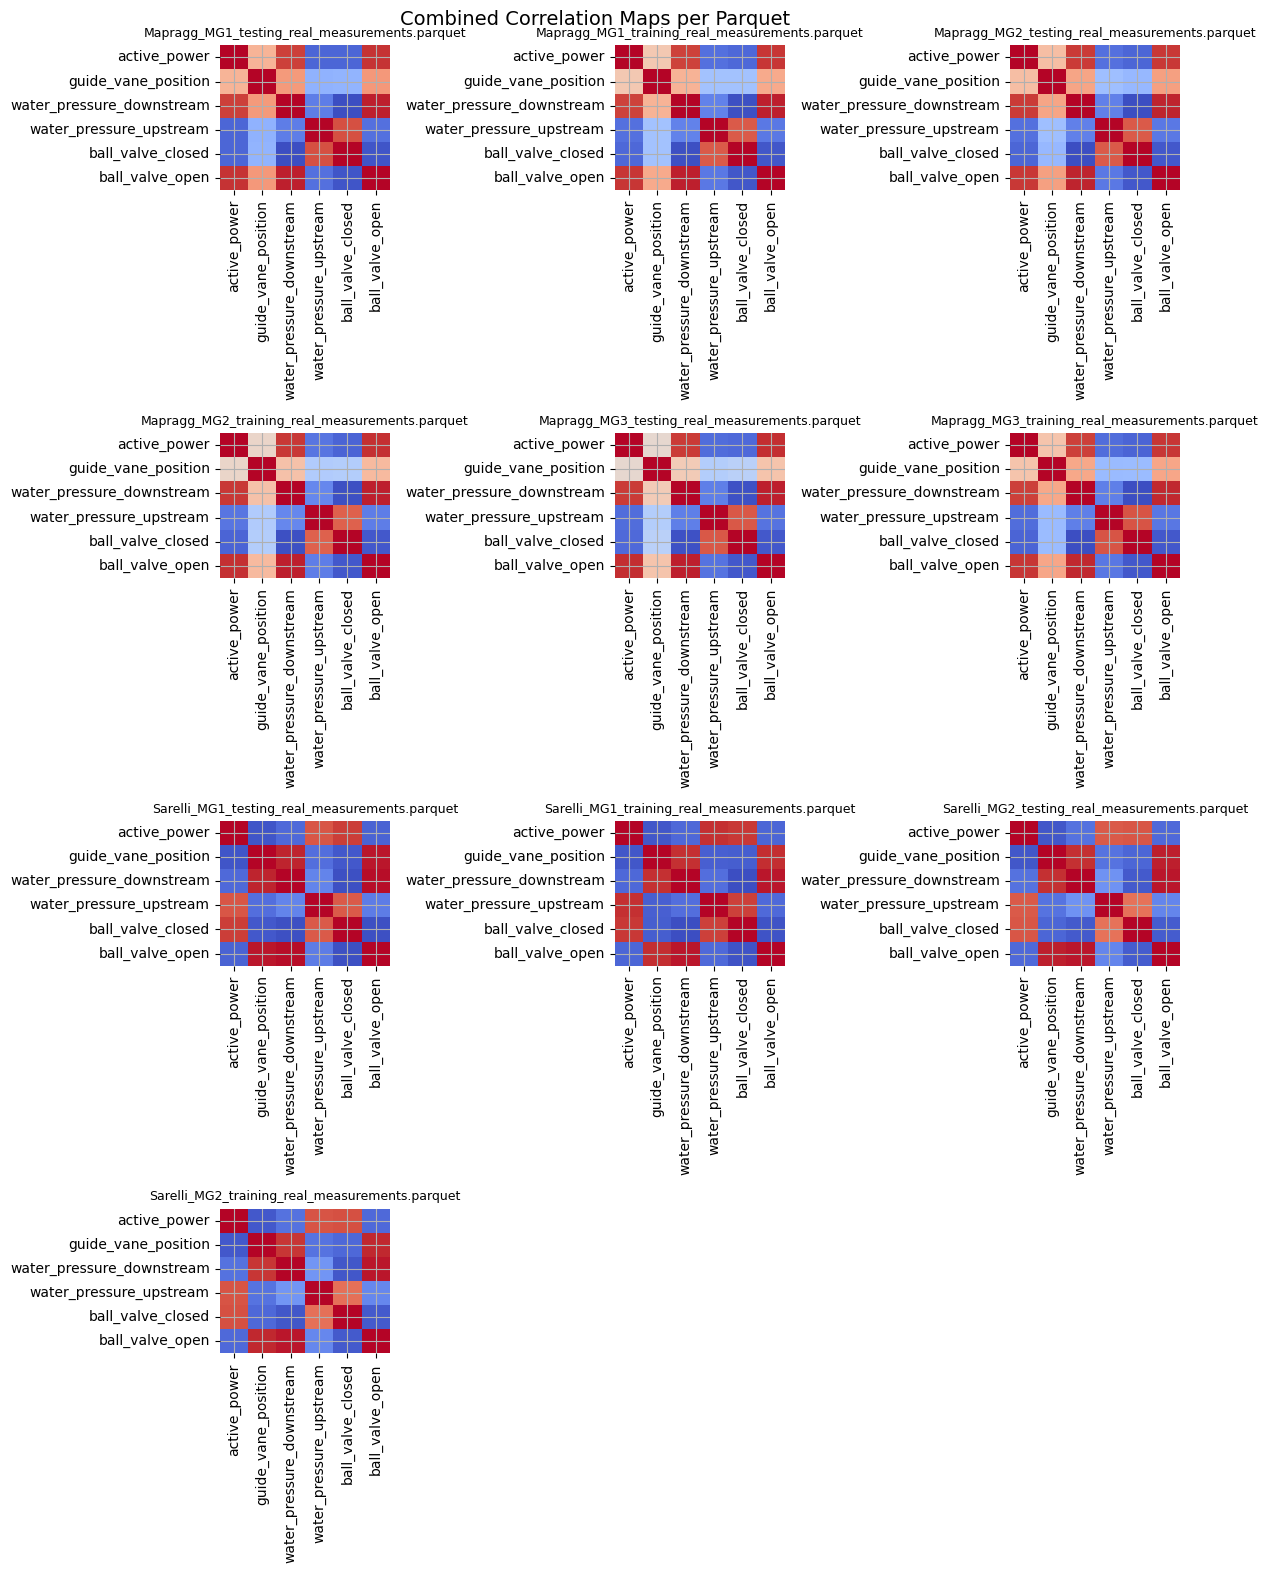

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math


# ----------------------------------------------------------
#  Compute correlation matrix for ONE segment
# ----------------------------------------------------------
def compute_segment_corr(seg_dict):
    df = None
    for sig, seg in seg_dict.items():
        if sig in ["stage", "machine_group", "dataset_type"]:
            continue
        
        tmp = seg[["t0_sec", "value"]].copy()
        tmp = tmp.rename(columns={"value": sig}).set_index("t0_sec")

        df = tmp if df is None else df.join(tmp, how="outer")

    df = df.sort_index().ffill()
    return df.corr()


# ----------------------------------------------------------
#  Compute per-parquet correlations & plot them all together
# ----------------------------------------------------------
def compute_all_parquet_correlations(all_segments):

    aggregated_corrs = {}

    # Collect all parquet names
    parquet_names = list(all_segments.keys())
    n_files = len(parquet_names)

    # One big figure
    cols = 3   # adjust if you like
    rows = math.ceil(n_files / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for ax, filename in zip(axes, parquet_names):

        group = all_segments[filename]

        signals = {
            "active_power": group["active_power"],
            "guide_vane_position": group["guide_vane_position"],
            "water_pressure_downstream": group["water_pressure_downstream"],
            "water_pressure_upstream": group["water_pressure_upstream"],
            "ball_valve_closed": group["ball_valve_closed"],
            "ball_valve_open": group["ball_valve_open"]
        }

        n_segments = len(signals["active_power"])
        segment_corrs = []

        # ----- Correlate each segment individually -----
        for seg_idx in range(n_segments):
            per_seg_dict = {sig: signals[sig][seg_idx] for sig in signals}
            corr = compute_segment_corr(per_seg_dict)
            segment_corrs.append(corr)

        # ----- Average across segments -----
        combined_corr = sum(segment_corrs) / len(segment_corrs)
        aggregated_corrs[filename] = combined_corr

        # ----- Plot in the combined figure -----
        sns.heatmap(
            combined_corr, annot=False, cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, cbar=False
        )
        ax.set_title(filename, fontsize=9)

    # Hide leftover empty axes
    for i in range(len(parquet_names), len(axes)):
        axes[i].axis("off")

    fig.suptitle("Combined Correlation Maps per Parquet", fontsize=14)
    plt.tight_layout()
    plt.show()

    return aggregated_corrs


# ----------------------------------------------------------
#  EXECUTE
# ----------------------------------------------------------
per_parquet_corr = compute_all_parquet_correlations(all_segments)


In [ ]:
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline

_raw_cache = {}

def load_raw(filename):
    # Handle both full paths and just filenames
    original_filename = filename
    if not os.path.exists(filename) and not os.path.isabs(filename):
        # If file doesn't exist and it's not an absolute path, try prepending 'data/'
        filename = os.path.join('data', os.path.basename(filename))
    
    # Use the resolved filename for caching
    if filename in _raw_cache:
        return _raw_cache[filename]
    
    df = pd.read_parquet(filename)

    # fix timestamp
    if not pd.api.types.is_datetime64_any_dtype(df["ts"]):
        df["ts"] = pd.to_datetime(df["ts"])

    if getattr(df["ts"].dt, "tz", None) is not None:
        df["ts"] = df["ts"].dt.tz_convert(None)

    df = df.sort_values("ts")

    df = df.merge(df_mapping, on="signal_id", how="left")

    _raw_cache[filename] = df
    return df


# ---------------------------------------------------------------------------
# BUILD FULL UI FOR ONE FILE
# ---------------------------------------------------------------------------

def build_viewer_for_file(filename):
    df = load_raw(filename)
    if df.empty:
        return widgets.HTML("No data in this file.")

    # compute slider bounds
    tmin = df["ts"].min().timestamp()
    tmax = df["ts"].max().timestamp()

    if tmin >= tmax:
        tmin -= 1
        tmax += 1

    # --- RECREATE SLIDERS (IMPORTANT FIX) ---
    time_slider = widgets.FloatSlider(
        description="Center",
        min=tmin,
        max=tmax,
        value=tmin,
        step=1.0,
        continuous_update=False
    )

    window_slider = widgets.FloatSlider(
        value=600,
        min=10,
        max=4*3600,
        step=10,
        description="Window (sec)",
        continuous_update=False
    )

    # plot function using closure variables
    def plot_window(center_time, window_sec):
        t0 = pd.to_datetime(center_time, unit="s")
        half = pd.Timedelta(seconds=window_sec / 2)
        t_start = t0 - half
        t_end   = t0 + half

        d = df[(df["ts"] >= t_start) & (df["ts"] <= t_end)]
        if d.empty:
            print("No data in this window.")
            return

        signals = [
            "active_power",
            "guide_vane_position",
            "water_pressure_downstream",
            "water_pressure_upstream",
            "ball_valve_closed",
            "ball_valve_open",
        ]
        signals = [s for s in signals if s in d["signal_name"].unique()]

        fig, axes = plt.subplots(len(signals), 1,
                                 figsize=(12, 2.5 * len(signals)),
                                 sharex=True)
        if len(signals) == 1:
            axes = [axes]

        for ax, sig in zip(axes, signals):
            sub = d[d["signal_name"] == sig]
            if set(sub["type_id"].unique()) == {"Bool"}:
                ax.plot(sub["ts"], sub["value"], ".", markersize=6)
            else:
                ax.plot(sub["ts"], sub["value"], linewidth=1)
            ax.set_ylabel(sig)
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Time")
        plt.tight_layout()
        plt.show()

    # create an interactive output panel linked to the new sliders
    out = interactive_output(
        plot_window,
        {"center_time": time_slider, "window_sec": window_slider}
    )

    return VBox([
        HBox([time_slider, window_slider]),
        out
    ])


# ---------------------------------------------------------------------------
# MASTER FILE DROPDOWN THAT REBUILDS THE ENTIRE INTERFACE
# ---------------------------------------------------------------------------

file_dropdown = widgets.Dropdown(
    options=sorted(parquet_files),
    description="Parquet"
)

ui_box = VBox([])

def on_file_change(change):
    clear_output(wait=True)
    display(file_dropdown, ui_box)

    ui_box.children = [build_viewer_for_file(file_dropdown.value)]

file_dropdown.observe(on_file_change, names="value")

display(file_dropdown)
ui_box.children = [build_viewer_for_file(file_dropdown.value)]


Dropdown(description='Parquet', index=1, options=('data/Mapragg_MG1_testing_real_measurements.parquet', 'data/…


=== Processing data/Mapragg_MG1_testing_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

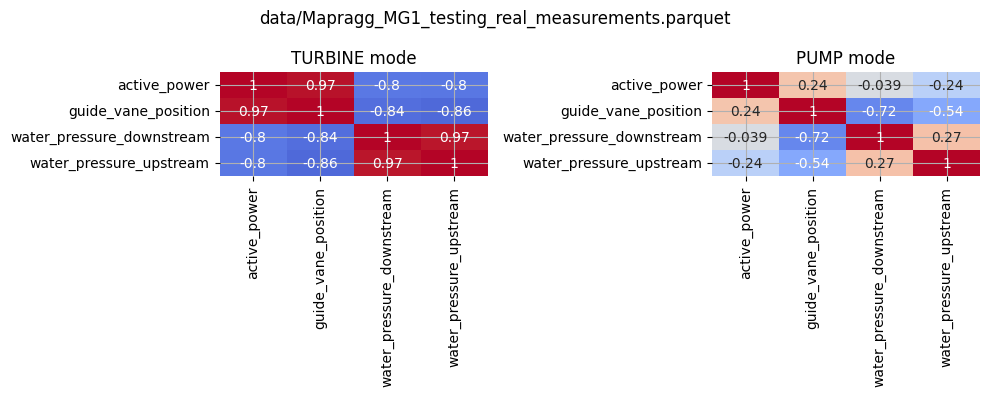


=== Processing data/Mapragg_MG1_training_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

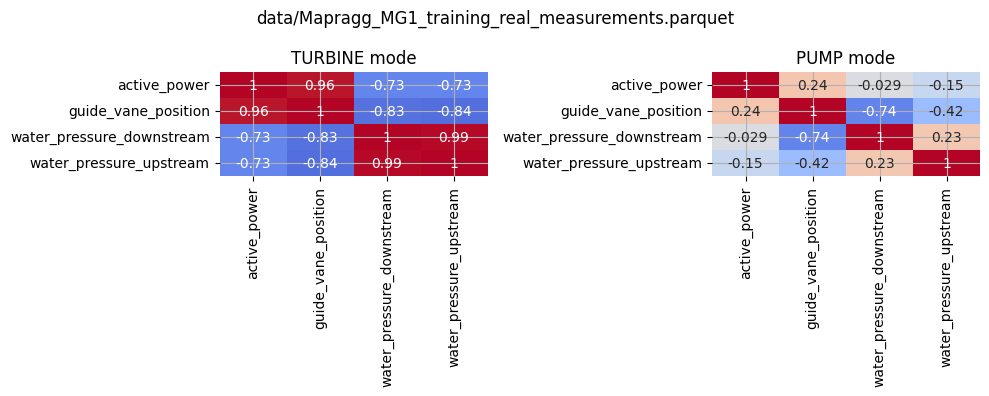


=== Processing data/Mapragg_MG2_testing_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

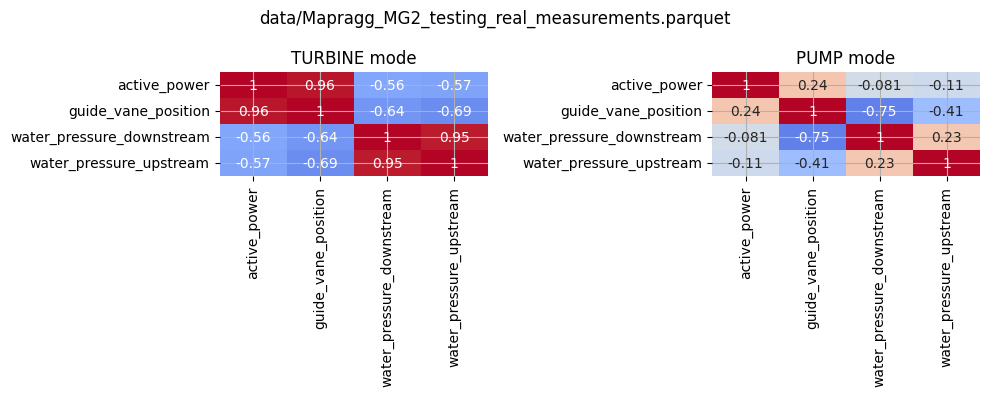


=== Processing data/Mapragg_MG2_training_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

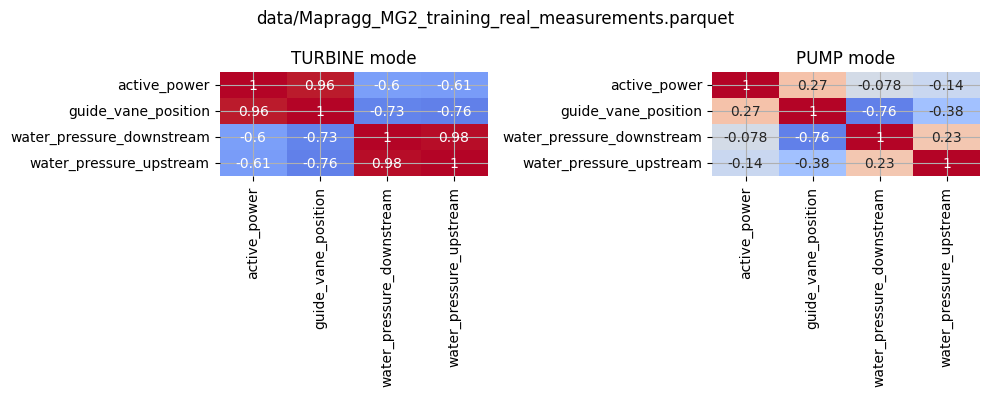


=== Processing data/Mapragg_MG3_testing_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

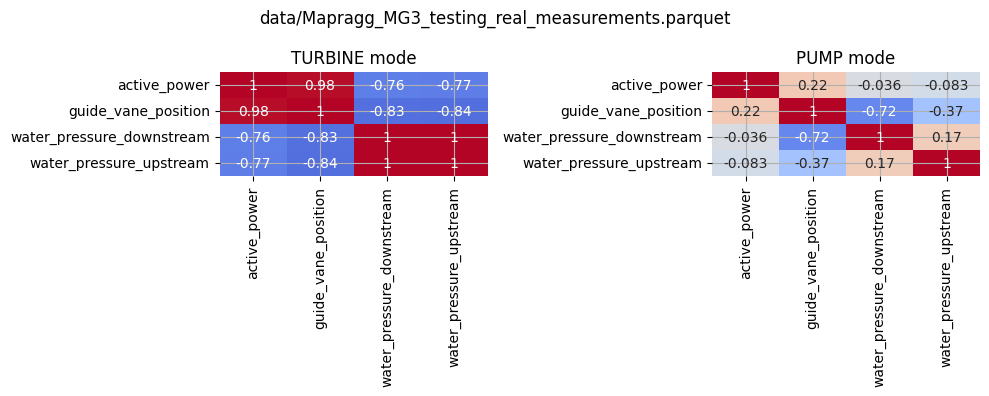


=== Processing data/Mapragg_MG3_training_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

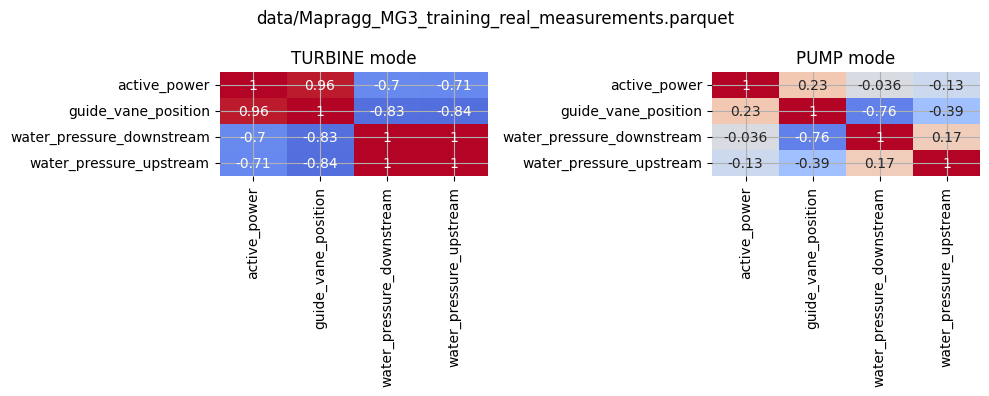


=== Processing data/Sarelli_MG1_testing_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

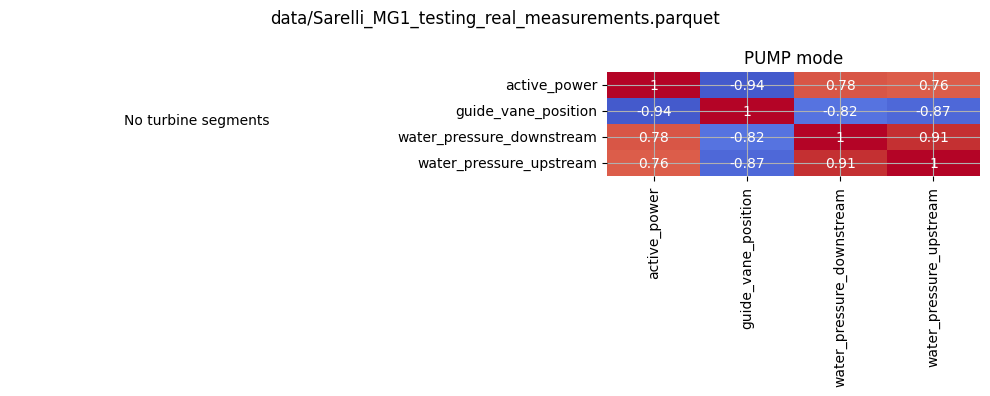


=== Processing data/Sarelli_MG1_training_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

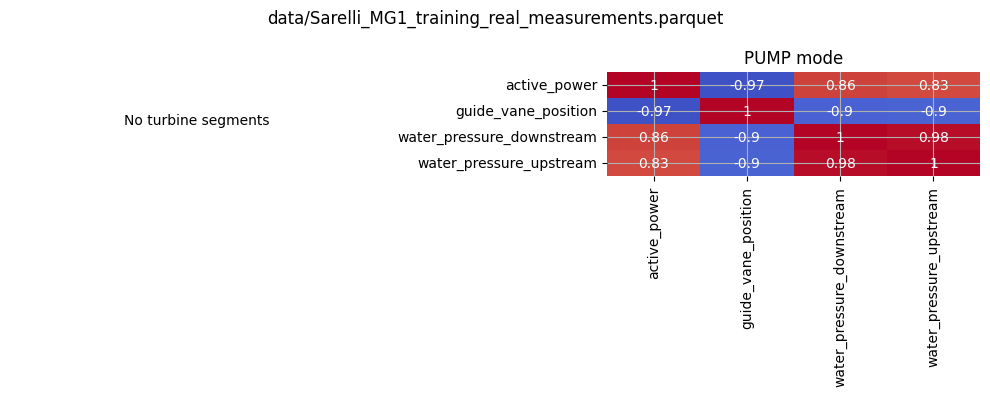


=== Processing data/Sarelli_MG2_testing_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

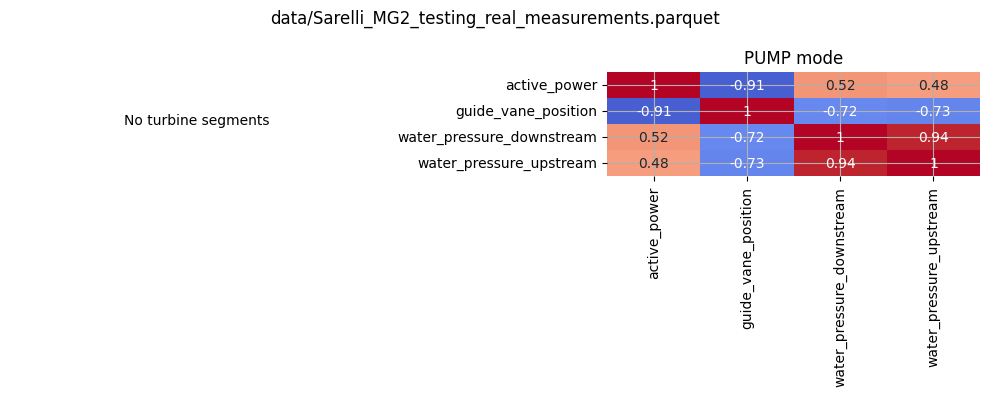


=== Processing data/Sarelli_MG2_training_real_measurements.parquet ===


/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ap["mode"] = np.select(
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
/var/folders/46/y0431pbj0sl3y6mcthks8j1r0000gn/T/ipykernel_97321/986709251.py:53: FutureWarning: 'S' is deprec

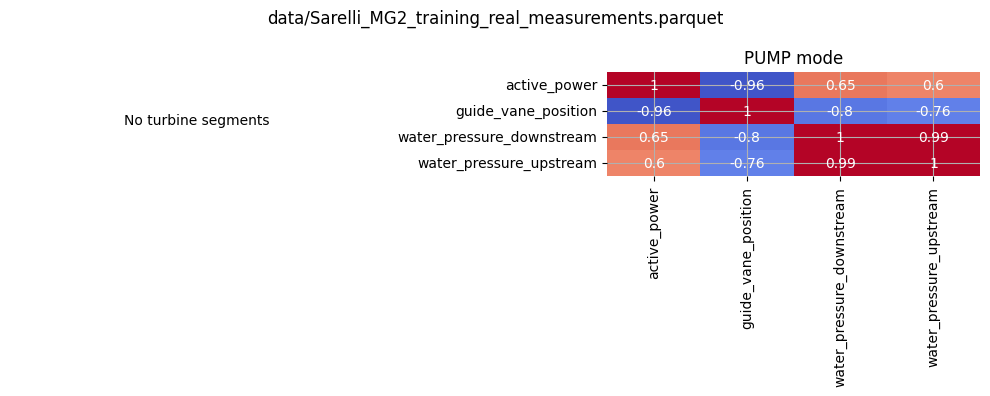

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Add turbine/pump/idle mode classification
# ---------------------------------------------------------
def add_mode_column(df, gen_thr=5.0, pump_thr=-5.0):
    df = df.sort_values("ts").copy()

    ap = df[df["signal_name"] == "active_power"]
    if ap.empty:
        df["mode"] = "unknown"
        return df

    p = ap["value"].values
    ap["mode"] = np.select(
        [p >= gen_thr, p <= pump_thr],
        ["turbine", "pump"],
        default="idle"
    )

    df = df.merge(ap[["ts", "mode"]], on="ts", how="left")
    df["mode"] = df["mode"].ffill().bfill()
    return df


# ---------------------------------------------------------
# 2. Split into continuous mode segments
# ---------------------------------------------------------
def split_into_mode_segments(df):
    df = df.sort_values("ts").copy()
    segid = (df["mode"] != df["mode"].shift()).cumsum()
    segments = []
    for seg_id, seg in df.groupby(segid):
        mode = seg["mode"].iloc[0]
        segments.append((mode, seg))
    return segments


# ---------------------------------------------------------
# 3. Uniformly resample each signal in the segment
# ---------------------------------------------------------
def resample_segment(seg, signals, rate=1.0):
    dt = 1.0 / rate
    per_sig = {}

    for sig in signals:
        tmp = seg[seg["signal_name"] == sig][["ts", "value"]]
        if tmp.empty:
            continue
        tmp = tmp.set_index("ts").resample(f"{int(dt)}S").mean().ffill()
        per_sig[sig] = tmp

    if not per_sig:
        return None

    # join everything on timestamp
    df_joined = None
    for sig, df_sig in per_sig.items():
        if df_joined is None:
            df_joined = df_sig.rename(columns={"value": sig})
        else:
            df_joined = df_joined.join(df_sig.rename(columns={"value": sig}), how="outer")

    return df_joined.ffill().dropna()


# ---------------------------------------------------------
# 4. Compute correlations per segment and combine per mode
# ---------------------------------------------------------
def correlations_per_parquet(df, rate=1.0):

    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
    ]

    df = add_mode_column(df)
    mode_segments = split_into_mode_segments(df)

    results = {"turbine": [], "pump": [], "idle": []}

    for mode, seg in mode_segments:
        if mode not in results:
            continue

        df_resampled = resample_segment(seg, signals, rate)
        if df_resampled is None:
            continue
        if len(df_resampled) < 10:
            continue

        results[mode].append(df_resampled.corr())

    # Average over segments (if available)
    combined = {}
    for mode in results:
        if results[mode]:
            combined[mode] = sum(results[mode]) / len(results[mode])
        else:
            combined[mode] = None

    return combined


# ---------------------------------------------------------
# 5. Plot turbine / pump maps for a single parquet
# ---------------------------------------------------------
def plot_correlation_maps(filename, rate=1.0):
    print(f"\n=== Processing {filename} ===")

    # load your parquet + merge mapping
    df = pd.read_parquet(filename)
    if not pd.api.types.is_datetime64_any_dtype(df["ts"]):
        df["ts"] = pd.to_datetime(df["ts"])
    if getattr(df["ts"].dt, "tz", None) is not None:
        df["ts"] = df["ts"].dt.tz_convert(None)
    df = df.merge(df_mapping, on="signal_id", how="left")
    df = df.sort_values("ts")

    corrs = correlations_per_parquet(df, rate=rate)

    modes = ["turbine", "pump"]
    fig, axes = plt.subplots(1, len(modes), figsize=(5 * len(modes), 4))

    if len(modes) == 1:
        axes = [axes]

    for ax, mode in zip(axes, modes):
        if corrs[mode] is None:
            ax.text(0.5, 0.5, f"No {mode} segments", ha="center")
            ax.axis("off")
            continue

        sns.heatmap(
            corrs[mode],
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            ax=ax,
            cbar=False,
        )
        ax.set_title(f"{mode.upper()} mode")

    plt.suptitle(filename)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 6. Run on all parquets
# ---------------------------------------------------------
for pq in parquet_files:
    plot_correlation_maps(pq, rate=1.0)
#----------------------------------
# 5. Plot all mode correlations
# -----------------------------------------------------------
def plot_mode_correlations(avg_corr):
    modes = list(avg_corr.keys())
    n = len(modes)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

    if n == 1:
        axes = [axes]

    for ax, mode in zip(axes, modes):
        sns.heatmap(avg_corr[mode],
                    annot=True, cmap="coolwarm", vmin=-1, vmax=1,
                    ax=ax, cbar=False)
        ax.set_title(f"{mode.upper()} mode")

    plt.tight_layout()
    plt.show()


In [35]:
import ipywidgets as widgets
from ipywidgets import interactive_output, VBox, HBox
from IPython.display import display
import matplotlib.pyplot as plt

%matplotlib inline

# ----------------------------------------------------
# PLOT ONE SEGMENT (raw, no sampling modifications)
# ----------------------------------------------------
def show_raw_segment(filename, seg_index):

    if filename not in all_segments:
        print("No data found for this file.")
        return

    group = all_segments[filename]

    # We use active_power list only to know number of segments
    ref_segments = group["active_power"]

    if len(ref_segments) == 0:
        print("This file has no segments.")
        return

    if seg_index >= len(ref_segments):
        print(f"Segment index {seg_index} out of range.")
        return

    # Info
    stage         = group["stage"]
    machine_group = group["machine_group"]
    dataset_type  = group["dataset_type"]

    # The signals to plot (same order as in your original code)
    signals = [
        "active_power",
        "guide_vane_position",
        "water_pressure_downstream",
        "water_pressure_upstream",
        "ball_valve_closed",
        "ball_valve_open",
    ]

    fig, axes = plt.subplots(len(signals), 1,
                             figsize=(12, 2.4*len(signals)),
                             sharex=True)

    if len(signals) == 1:
        axes = [axes]

    # Plot each signal for this segment
    for ax, sig in zip(axes, signals):
        seg_list = group[sig]
        seg = seg_list[seg_index]    # <-- raw segment (already normalized)

        if sig in ["ball_valve_closed", "ball_valve_open"]:
            ax.plot(seg["t0_sec"], seg["value"], ".", markersize=6)
        else:
            ax.plot(seg["t0_sec"], seg["value"], linewidth=1)

        ax.set_ylabel(sig, fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("t0_sec (raw segment time)", fontsize=10)

    fig.suptitle(f"{filename} — Segment {seg_index}\n({stage}, {machine_group}, {dataset_type})",
                 fontsize=12, y=1.02)

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------
# WIDGETS
# ----------------------------------------------------
file_dropdown = widgets.Dropdown(
    options=sorted(list(all_segments.keys())),
    description="Parquet"
)

seg_slider = widgets.IntSlider(
    min=0, max=0, step=1, value=0,
    description="Segment"
)

# Update segment slider whenever parquet changes
def update_segment_slider(*args):
    fname = file_dropdown.value
    if fname in all_segments:
        seg_slider.max = max(0, len(all_segments[fname]["active_power"]) - 1)
    else:
        seg_slider.max = 0
    seg_slider.value = 0

file_dropdown.observe(update_segment_slider, names="value")
update_segment_slider()

# Hook viewer to widgets
out = interactive_output(
    show_raw_segment,
    {
        "filename": file_dropdown,
        "seg_index": seg_slider
    }
)

# Display UI
display(VBox([file_dropdown, seg_slider, out]))
